### Visualizing data from OpenAlex and Scopus manual search

In [ ]:
#% pip install numpy pandas seaborn matplotlib openpxyl

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import openpyxl # For working with Excel files

In [3]:
# Import Excel file
df = pd.read_excel('Figure4_Publication_aggregate.xlsx', sheet_name='Combined')

# Reshape to long format
df_long = df.melt(id_vars='Year',
                  value_vars=['Scopus', 'OpenAlex'],
                  var_name='Source',
                  value_name='Count')

df_long['Year'] = df_long['Year'].astype(str)
#df_long['Year'] = pd.Categorical(df_long['Year'], ordered=True)
df_long['Source'] = pd.Categorical(df_long['Source'], categories=['Scopus', 'OpenAlex'], ordered=True)

# Cumulative sum for both OpenAlex and Scopus
df_long['Cumulative'] = df_long.groupby('Source',
                                        observed=False,
                                        )['Count'].cumsum()

df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Year        34 non-null     object  
 1   Source      34 non-null     category
 2   Count       34 non-null     int64   
 3   Cumulative  34 non-null     int64   
dtypes: category(1), int64(2), object(1)
memory usage: 1.1+ KB


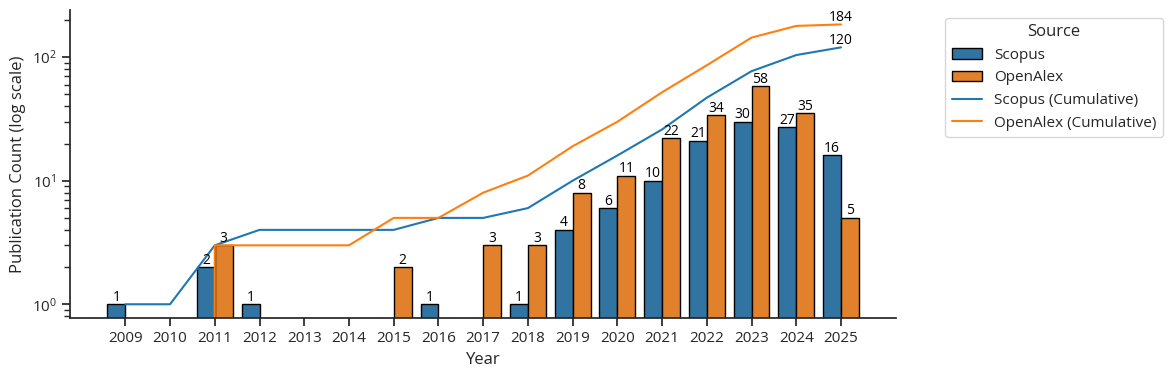

In [4]:
# Set seaborn theme
custom_params = {"axes.spines.right": False, 
                "axes.spines.top": False,
                "axes.grid": False, 
                "font.family": "Open Sans",
                "font.size": 14
                 }
sns.set_theme(style="ticks", rc=custom_params)

# Plot bar charts
plt.figure(figsize=(12, 4))
bar = sns.barplot(data=df_long, 
                  x='Year', 
                  y='Count', 
                  hue='Source', 
                  palette='tab10', 
                  edgecolor='black',
                  )

# Add cumulative line plot
line = sns.lineplot(data=df_long,
                    #same axis as bar plot, get axis from bar plot
                    ax=bar,
                    x='Year',
                    y='Cumulative', 
                    hue='Source',
                    palette='tab10',
                    markers=True, 
                    dashes=True, 
                    #legend='full',
                    )

# Add text annotations for bar plot
for p in bar.patches:
    bar.annotate(format(p.get_height(), '.0f'),
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 fontsize=10, color='black',
                 xytext=(0, 5), textcoords='offset points')
    
# Add text annotations for line plot, only the grand total of publications at the end of each line
for source in df_long['Source'].unique():
    last_value = df_long[df_long['Source'] == source].iloc[-1]['Cumulative']
    year = df_long[df_long['Source'] == source].iloc[-1]['Year']
    line.annotate(format(last_value, '.0f'),
                  (year, last_value),
                  ha='center', va='center',
                  fontsize=10, color='black',
                  xytext=(0, 5), textcoords='offset points')

# Set log scale for y-axis
bar.set_yscale('log')
line.set_yscale('log')

plt.xlabel('Year')
plt.ylabel('Publication Count (log scale)')

# Append "(Cumulative)" to line plot labels
bar_handles, bar_labels = bar.get_legend_handles_labels()
line_handles, line_labels = line.get_legend_handles_labels()

line_labels = [label + ' (Cumulative)' for label in line_labels]
plt.legend(bar_handles[0:2] + line_handles[2:4],
           bar_labels[0:2] + line_labels[2:4],
           title='Source',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig('Figure4_Publication_Comparison_OpenAlex_Scopus.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()